# 1. Data
CIFAR10 is a subset of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The dataset is available at CIFAR-10 and CIFAR-100 datasets (toronto.edu) and can also be loaded directly from TensorFlow using tf.keras.datasets.cifar10.load_data.

**Problem Statement:**
Image classification is an important part of computer vision systems. Equipped with a digital camera and a single board computer (such as a Raspberry Pi), smart technology can capture an image, determine what is in the image using a classification model, and then take an action based on that information. As a warmup exercise to develop such technology, consider that you are tasked to classify images from the CIFAR10 dataset. You are to build your own CNN model for this, both from scratch and from an existing model via transfer learning and fine tuning.
## 1.1 Load Data
Load CIFAR10 dataset into training and testing, features and labels numpy arrays using cifar10.load_data. Using markdown, list the 10 classes. 

In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [2]:
(features_train, label_train), (features_test, label_test) = cifar10.load_data()

In [3]:
# Printing the unique labels in the training set
set(label_train.flatten())

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

### Classes obtained
We obtained the 10 classes to be the integer numbers from 0 to 9 (a total of 10 classes).

## 1.2 Bar Plot Checking for Classes Distribution
Create a bar plot using seaborn.barplot of the number of elements in each category of the entire dataset. Use markdown to comment on how well balanced the dataset is.

Text(0.5, 1.0, 'Distribution of CIFAR-10 Classes')

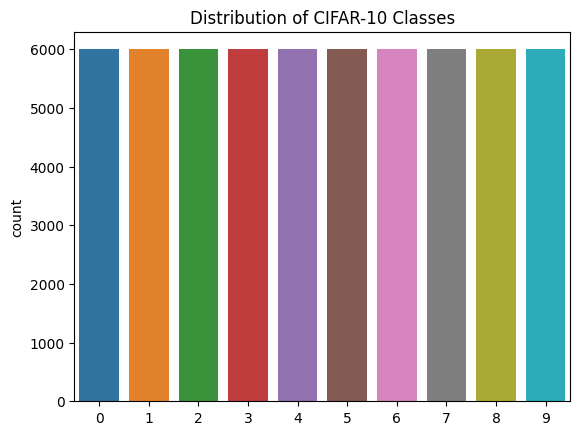

In [4]:
# Bar plot goes here
entire_dataset = list(label_train.flatten()) + list(label_test.flatten())
sns.countplot(x=entire_dataset)
plt.title('Distribution of CIFAR-10 Classes')

The dataset is perfectly balanced. Each one of the classes has exactly 6000 instances on it for a total of 60000 instances.

## 1.3 Splitting the dataset
Use sklearn.model_selection.train_test_split to split the test set into test and validation sets choosing appropriate proportions. 

In [5]:
label_train = label_train.flatten()
label_test = label_test.flatten()

features_val, features_test, label_val, label_test = train_test_split(features_test,
                                                                    label_test,
                                                                    test_size=0.5,
                                                                    random_state=42)

print(f"Training set shape: {features_train.shape}, {label_train.shape}")
print(f"Validation set shape: {features_val.shape}, {label_val.shape}")
print(f"Test set shape: {features_test.shape}, {label_test.shape}")

Training set shape: (50000, 32, 32, 3), (50000,)
Validation set shape: (5000, 32, 32, 3), (5000,)
Test set shape: (5000, 32, 32, 3), (5000,)


## 1.4 Data Generators
Create train, test, and validation data generators using tensorflow.keras.preprocessing.image.ImageDataGenerator; each should scale the data by dividing by 255, and the training generator should also use data augmentation. 

In [6]:
train_img_gen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    rotation_range=20,          # random rotations (degrees)
    zoom_range=0.2,             # random zoom in/out
    shear_range=0.15,           # shear transformations
    brightness_range=[0.7, 1.3],# random brightness adjustments
    fill_mode='nearest',        # how to fill missing pixels after transforms
    channel_shift_range=20.0,   # random channel intensity shifts
    vertical_flip=False,
)
val_img_gen = ImageDataGenerator(rescale=1./255)
test_img_gen = ImageDataGenerator(rescale=1./255)

batch_size=16
img_height = 32
img_width = 32

Running the flow functions on the CIFAR10 data

In [7]:
train_data_gen = train_img_gen.flow(features_train, label_train, batch_size=batch_size)
val_data_gen = val_img_gen.flow(features_val, label_val, batch_size=batch_size)
test_data_gen = test_img_gen.flow(features_test, label_test, batch_size=batch_size)

# 2. Modeling


## 2.1 CNN construction
Use tf.keras.Sequential to create a convolutional neural network. Use at least two convolution layers and at least two pooling layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

## 2.2 Model Compiling
Compile the model with a choice of optimizer, sparse_categorical_crossentropy for the loss function, and set the metrics argument equal to ['accuracy'].

## 2.3 Model Training
Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures other hyperparameters to improve upon the results.

In [8]:
np.random.seed(8)
tf.random.set_seed(8)
 
model = tf.keras.Sequential([
    layers.Conv2D(64, 3, activation='relu', input_shape=(img_height, img_width ,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dense (Dense)               (None, 128)               5

In [9]:
optimizer = tf.keras.optimizers.Adam(0.001)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

In [10]:
model.fit(
    train_data_gen,
    steps_per_epoch=len(features_train) // batch_size,
    epochs=10,
    validation_data=val_data_gen,
    validation_steps=len(features_val) // batch_size
)

Epoch 1/10
3125/3125 [==============================] - 69s 22ms/step - loss: 1.5751 - accuracy: 0.4320 - val_loss: 1.2167 - val_accuracy: 0.5669
Epoch 2/10
3125/3125 [==============================] - 75s 24ms/step - loss: 1.2763 - accuracy: 0.5497 - val_loss: 1.0420 - val_accuracy: 0.6314
Epoch 3/10
3125/3125 [==============================] - 82s 26ms/step - loss: 1.1894 - accuracy: 0.5794 - val_loss: 1.0586 - val_accuracy: 0.6222
Epoch 4/10
3125/3125 [==============================] - 93s 30ms/step - loss: 1.1209 - accuracy: 0.6039 - val_loss: 1.1715 - val_accuracy: 0.5791
Epoch 5/10
3125/3125 [==============================] - 94s 30ms/step - loss: 1.0779 - accuracy: 0.6203 - val_loss: 0.9521 - val_accuracy: 0.6639
Epoch 6/10
3125/3125 [==============================] - 93s 30ms/step - loss: 1.0535 - accuracy: 0.6298 - val_loss: 0.8599 - val_accuracy: 0.7009
Epoch 7/10
3125/3125 [==============================] - 94s 30ms/step - loss: 1.0201 - accuracy: 0.6431 - val_loss: 0.8668 -

# 3. Conclusion
## 3.1 Best model selection: Model 5